<a href="https://colab.research.google.com/github/Shrawanpandit/ImageProcessing-Lab-works/blob/main/ImageProcessingLab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

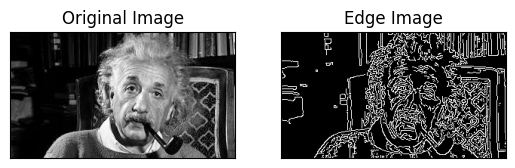

In [5]:
# write a program to detect edge of a image
import cv2
import numpy as np
from matplotlib import pyplot as plt
img =cv2.imread('download.jpg',0)
edges=cv2.Canny(img,100,200)

plt.subplot(121),plt.imshow(img,cmap='gray')
plt.title('Original Image'),plt.xticks([]),plt.yticks([])
plt.subplot(122),plt.imshow(edges,cmap='gray')
plt.title('Edge Image'),plt.xticks([]),plt.yticks([])

plt.show()

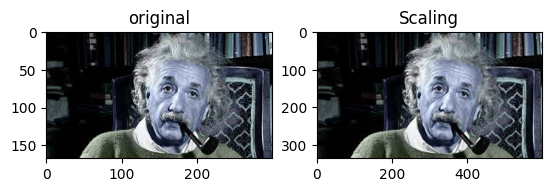

In [6]:
# Write a program to scale an image
import cv2
import numpy as np
from matplotlib import pyplot as plt
img = cv2.imread('download.jpg')
res = cv2.resize(img,None,fx=2, fy=2, interpolation = cv2.INTER_CUBIC)
height, width = img.shape[:2]
res = cv2.resize(img,(2*width, 2*height), interpolation = cv2.INTER_CUBIC)

plt.subplot(121),plt.imshow(img),plt.title('original')
#plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(res),plt.title('Scaling')
#plt.xticks([]), plt.yticks([])
plt.show()

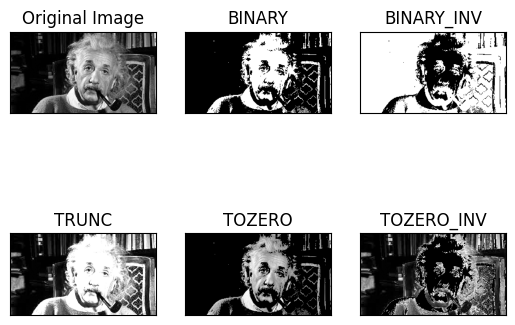

In [7]:
# Write a program showing a thresholding process on an image
import cv2
import numpy as np
from matplotlib import pyplot as plt
img = cv2.imread('download.jpg',0) # Corrected filename
ret,thresh1 = cv2.threshold(img,127,255,cv2.THRESH_BINARY)
ret,thresh2 = cv2.threshold(img,127,255,cv2.THRESH_BINARY_INV)
ret,thresh3 = cv2.threshold(img,127,255,cv2.THRESH_TRUNC)
ret,thresh4 = cv2.threshold(img,127,255,cv2.THRESH_TOZERO)
ret,thresh5 = cv2.threshold(img,127,255,cv2.THRESH_TOZERO_INV)
titles = ['Original Image','BINARY','BINARY_INV','TRUNC','TOZERO','TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]
for i in range(6):
    plt.subplot(2,3,i+1),plt.imshow(images[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()

## Log Transformation of an Image
Log transformation is a popular image enhancement technique that is often used to brighten the pixel values of an image. It helps in stretching the values of dark pixels while compressing the values of bright pixels, making details in the darker regions more visible.

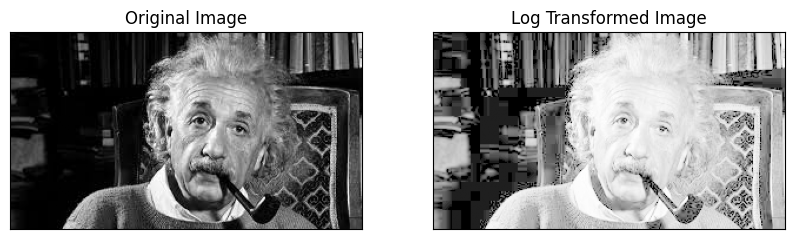

In [8]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load image in grayscale
img = cv2.imread('download.jpg', 0)

# Check if image loaded properly
if img is None:
    print("Error: Image not found!")
    exit()

# Convert image to float for log operation
img_float = np.float32(img)

# Apply log transformation
c = 255 / np.log(1 + np.max(img_float))

log_transformed_img = c * np.log(1 + img_float)

# Convert back to uint8
log_transformed_img = np.array(log_transformed_img, dtype=np.uint8)

# Display images
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.xticks([])
plt.yticks([])

plt.subplot(1, 2, 2)
plt.imshow(log_transformed_img, cmap='gray')
plt.title('Log Transformed Image')
plt.xticks([])
plt.yticks([])

plt.show()

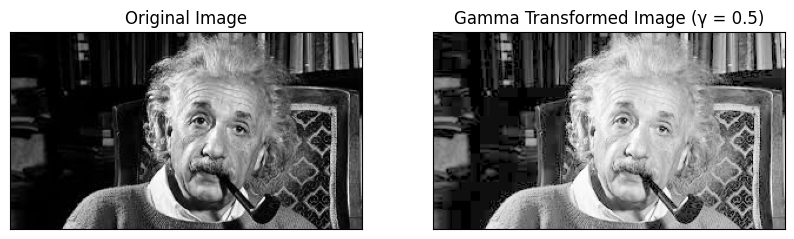

In [9]:
#Gamma transformation
import cv2
import numpy as np
from matplotlib import pyplot as plt


img = cv2.imread('download.jpg', 0)

if img is None:
    print("Error: Image not found!")


gamma =0.5
c = 1

img_normalized = img / 255.0

gamma_transformed = c * np.power(img_normalized, gamma)

gamma_transformed = np.uint8(gamma_transformed * 255)


plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.xticks([]), plt.yticks([])

plt.subplot(1, 2, 2)
plt.imshow(gamma_transformed, cmap='gray')
plt.title(f'Gamma Transformed Image (γ = {gamma})')
plt.xticks([]), plt.yticks([])

plt.show()

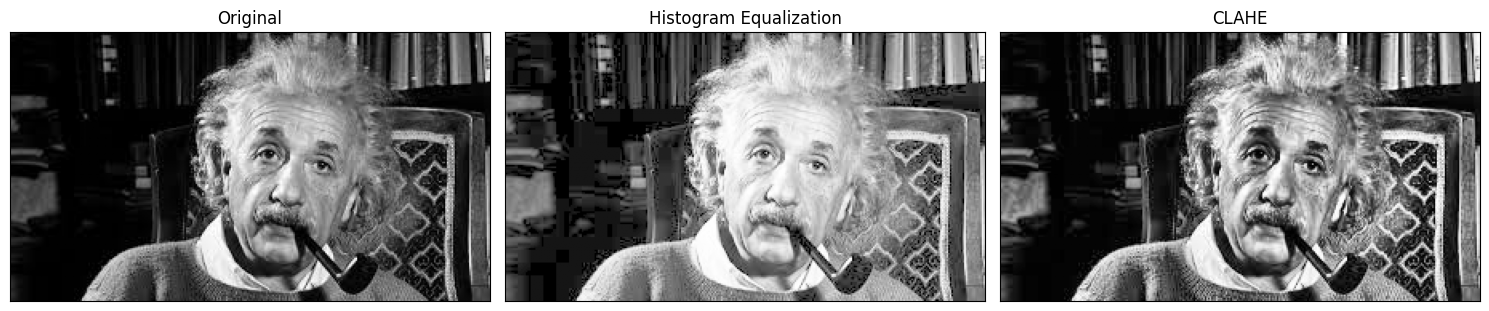

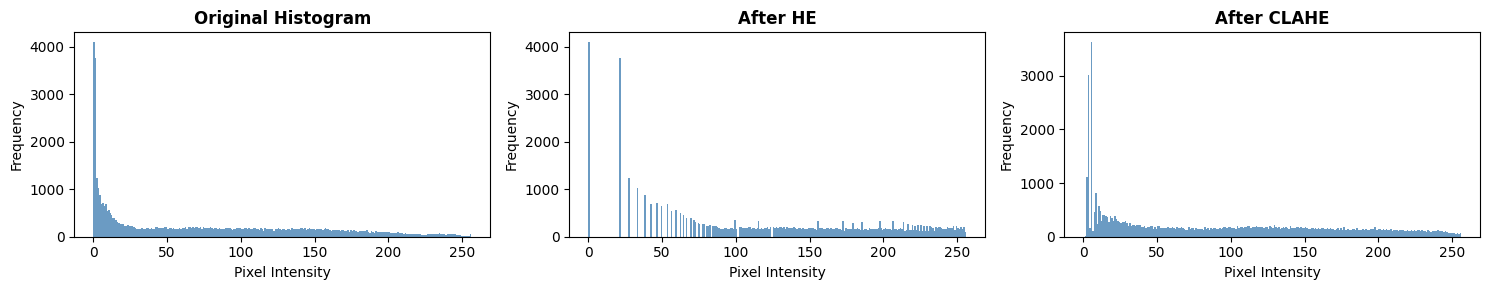

 Histogram Processing complete.


In [10]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

#PROGRAM 2 — Histogram Processing
# (Histogram Equalization & CLAHE)

def histogram_processing(img):
    # Standard Histogram Equalization
    hist_eq = cv2.equalizeHist(img)
    # CLAHE (Contrast Limited Adaptive Histogram Equalization)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    clahe_img = clahe.apply(img)

    # Plot images
    plt.figure(figsize=(15, 4))
    images_to_show = [img, hist_eq, clahe_img]
    titles_to_show = ['Original', 'Histogram Equalization', 'CLAHE']
    for i in range(len(images_to_show)):
        plt.subplot(1, 3, i + 1)
        plt.imshow(images_to_show[i], cmap='gray')
        plt.title(titles_to_show[i])
        plt.xticks([]), plt.yticks([])
    plt.tight_layout()
    plt.show()

    # Plot histograms
    fig, axes = plt.subplots(1, 3, figsize=(15, 3))
    for ax, image, title in zip(axes,
                                [img, hist_eq, clahe_img],
                                ['Original Histogram', 'After HE', 'After CLAHE']):
        ax.hist(image.ravel(), bins=256, range=(0, 256), color='steelblue', alpha=0.8)
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Pixel Intensity')
        ax.set_ylabel('Frequency')
    plt.tight_layout()
    plt.show()
    print(" Histogram Processing complete.")

# Load an image for demonstration (assuming 'download.jpg' exists and is a valid image)
img_gray = cv2.imread('download.jpg', 0)

# Check if image loaded properly
if img_gray is None:
    print("Error: Image not found for histogram processing!")
else:
    histogram_processing(img_gray)